#Clusterização com DBscan

## Importação das bibliotecas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN, KMeans
from sklearn.neighbors import NearestNeighbors

#seed
seed = 0
np.random.seed(seed)

## Carregar base de dados

In [ ]:
df = pd.read_csv('bi_data.csv', header=None)
df.head()

,0,1
0,-0.001364,0.994355
1,-0.001335,0.978548
2,-0.001308,0.963871
3,-0.001280,0.949193
4,-0.001251,0.933387


In [ ]:
df.shape

(6046, 2)

##Visualizar base

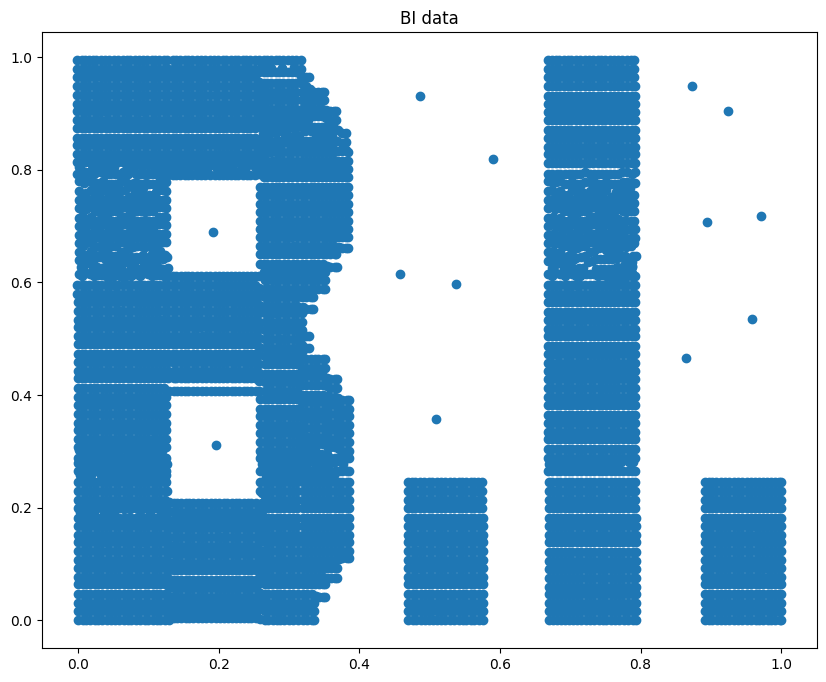

In [ ]:
plt.figure(figsize=(10,8))
plt.scatter(x=df[0], y=df[1])
plt.title('BI data')
plt.show()

##Rodar DBscan
Parâmetros:
- eps: especifica como os pontos próximos devem ser considerados para serem considerados parte de um cluster.
Se pequeno, grande parte dos dados não será agrupada.
Quanto maior, mais os clusters serão mesclados e a maioria dos objetos estará no mesmo cluster.

- min_samples: o número mínimo de pontos para formar uma região densa.
min_samples ??? D + 1.
Valores maiores geralmente são melhores para conjuntos de dados com ruído.


KNN
1. Para estimar os valores de 'eps' e 'min_samples', vamos utilizar o knn.
A ideia é calcular a distância média de cada registro para seus k vizinhos mais próximos. O valor de k deve ser especificado pelo usuário e corresponde ao 'min_samples'.
2. Em seguida, as k-distâncias são plotadas em ordem. O objetivo é determinar o 'joelho', que corresponde ao parâmetro ótimo de 'eps'.

In [ ]:
neighbors = 4
knn = NearestNeighbors(n_neighbors=neighbors).fit(df)
distances, indices = knn.kneighbors(df)
distance = sorted(distances[:,neighbors-1])

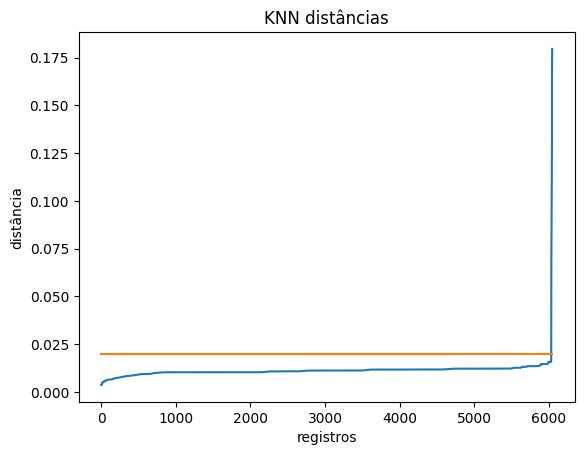

In [ ]:
# Distancias ordenadas
plt.plot(indices[:,0], distance)
plt.title('KNN distâncias')
plt.xlabel('registros')
plt.ylabel('distância')

# Determinar o eps pelo joelho do gráfico
eps=0.02
plt.plot([0,len(df)], [eps, eps])

plt.show()

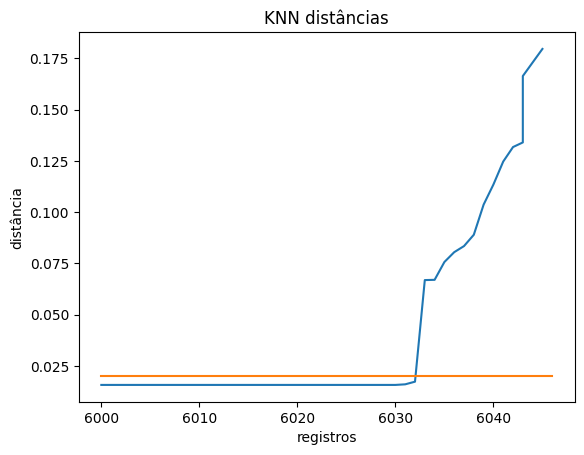

In [ ]:
# Distancias ordenadas (visualizar os outliers)
plt.plot(indices[6000::,0], distance[6000::])
plt.title('KNN distâncias')
plt.xlabel('registros')
plt.ylabel('distância')

# Determinar o eps pelo joelho do gráfico
eps=0.02
plt.plot([6000,len(df)], [eps, eps])

plt.show()

###DBscan

In [ ]:
model = DBSCAN(eps=eps, min_samples=neighbors)
model = model.fit(df)

In [ ]:
# Analisar quantidade de clusters e quantidade de registros em cada cluster
labels = model.labels_
labels

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
labels.shape


(6046,)

In [ ]:
# analisar cluster usando o pandas
pd.DataFrame(model.labels_).value_counts()

 0    3903
 2    1467
 3     340
 1     323
-1      13
Name: count, dtype: int64

In [ ]:
# analisar cluster usando o numpy
unique, counts = np.unique(labels, return_counts=True)
dict(zip(unique, counts))
# Cluster -1 é ruído.

{-1: 13, 0: 3903, 1: 323, 2: 1467, 3: 340}

list

'$\\mathdefault{2}$'

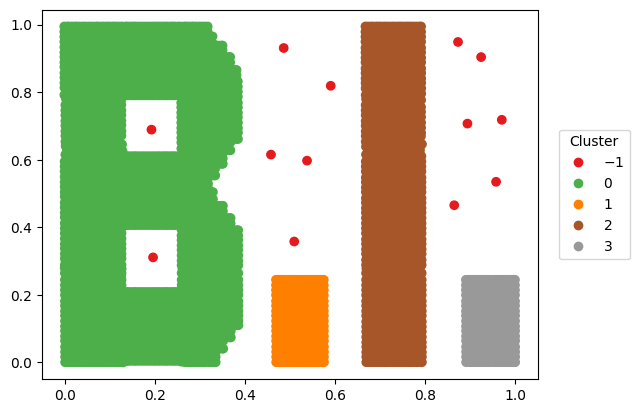

In [ ]:
# Gráfico da separação dos grupos formados
fig = plt.scatter(x=df[0], y=df[1], c=model.labels_, cmap='Set1')
handles, lbls = fig.legend_elements(prop="colors")
plt.legend(handles, lbls, loc='center right', bbox_to_anchor=(1.2, 0.5), title='Cluster')
plt.show()

In [ ]:
# Quais registros são ruído?
df[labels == -1]

,0,1
5670,0.486163,0.930649
5671,0.590654,0.818792
5672,0.537994,0.597315
5673,0.457886,0.615213
5674,0.509576,0.357942
5675,0.873466,0.948546
5676,0.924760,0.903803
5677,0.894400,0.706935
5678,0.970730,0.718121
5679,0.958036,0.534676


In [ ]:
df_sem_ruido = df[labels != -1]

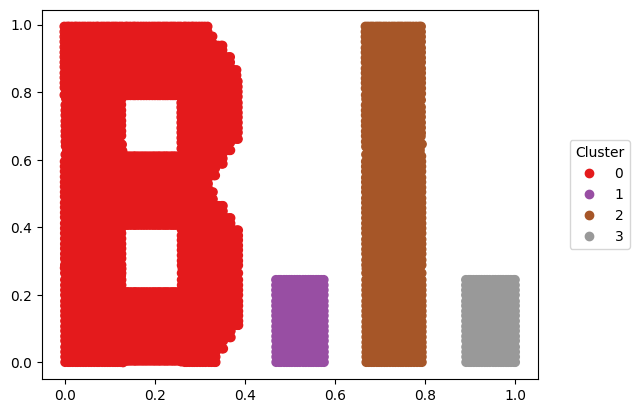

In [ ]:
# Gráfico da separação dos grupos formados (sem ruído)
fig = plt.scatter(x=df_sem_ruido[0], y=df_sem_ruido[1], c=model.labels_[model.labels_ !=-1], cmap='Set1')
handles, lbls = fig.legend_elements(prop="colors")
plt.legend(handles, lbls, loc='center right', bbox_to_anchor=(1.2, 0.5), title='Cluster')
plt.show()

In [ ]:
# Análise do agrupamento!

##Comparar com o Kmeans

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=seed)
kmeans = kmeans.fit(df_sem_ruido)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [ ]:
# Grupos de cada registro da base
kmeans.labels_

array([0, 0, 0, ..., 3, 3, 3], dtype=int32)

In [ ]:
kmeans.cluster_centers_

array([[0.18114952, 0.75797445],
       [0.73543401, 0.17263404],
       [0.73111199, 0.72454415],
       [0.18509562, 0.23604678]])

In [ ]:
# analisar cluster usando o pandas
pd.DataFrame(kmeans.labels_).value_counts()

3    1981
0    1922
1    1332
2     798
Name: count, dtype: int64

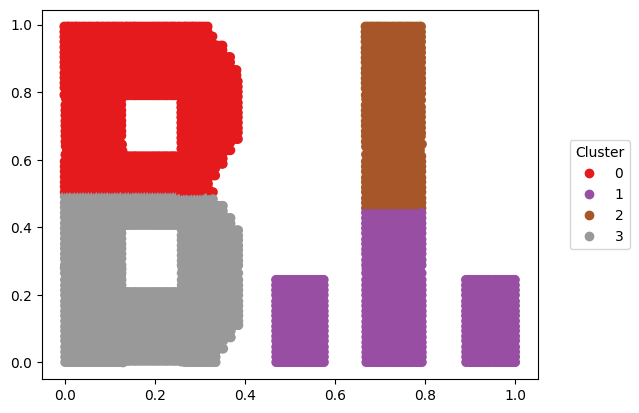

In [ ]:
# Gráfico da separação dos grupos formados
fig = plt.scatter(x=df_sem_ruido[0], y=df_sem_ruido[1], c=kmeans.labels_, cmap='Set1')
handles, labels = fig.legend_elements(prop="colors")
plt.legend(handles, labels, loc='center right', bbox_to_anchor=(1.2, 0.5), title='Cluster')
plt.show()

Para praticar! Avaliar o agrupamento hierarquico!

*   Item da lista
*   Item da lista

